In [ ]:
import pandas as pd
import numpy as np

In [2]:
splits = pd.read_csv("./random_kfolds/split.csv")
print(splits.head(2))
DIST_PATH = "../data/rnadist_f_all.h5"
dist = pd.read_hdf(DIST_PATH)
dist.head(2)

   fold_number partition                                                 id
0            0     train                   tmRNA_Stre.gord._TRW-29390_1-349
1            0     train  tRNA_tdbR00000055-Schizosaccharomyces_pombe-48...


id,5s_Acholeplasma-laidlawii-1,5s_Acidovorax-temperans-1,tmRNA_Stre.gord._TRW-29390_1-349,tRNA_tdbR00000055-Schizosaccharomyces_pombe-4896-Glu-3UC,srp_List.mono._U15684,5s_Methanothermobacter-thermautotrophicus-6,srp_Vibr.fisc._CP000020,srp_Baci.thur._D11412,grp1_a.I1.m.M.grisea.B2.ND1,5s_Saprospira-grandis-1,...,RNaseP_M.avium,tRNA_tdbR00000521-Bos_taurus-9913-Ini-CAU,grp1_a.I1.e.P.pachydermus.C1.SSU.943,5s_Pseudomonas-stutzeri-2,16s_T.maritima_domain3,5s_Bacillus-cereus-6,srp_Myco.aviu._AE016958,tmRNA_Heli.pylo._AE001503_1-383,5s_Triticum-aestivum-1,5s_Streptomyces-violaceus-1
id,,,,,,,,,,,,,,,,,,,,,
5s_Acholeplasma-laidlawii-1,0.000000,0.130435,0.805158,0.562500,0.799283,0.265625,0.776786,0.756458,0.782456,0.173554,...,0.763819,0.625000,0.795918,0.150000,0.817734,0.140351,0.696429,0.806789,0.200000,0.216667
5s_Acidovorax-temperans-1,0.130435,0.000000,0.819484,0.591304,0.802867,0.179688,0.747826,0.752768,0.778947,0.132231,...,0.756281,0.652174,0.798469,0.108333,0.815271,0.130435,0.756522,0.814621,0.191667,0.125000


In [3]:
splits["partition"] = splits["partition"].apply(
    lambda x: "train" if x in ["train", "valid"] else "test"
)

In [4]:
parts = list(splits.partition.unique())

In [5]:
split_0_test = splits.query("fold_number == 0 & partition == 'test'")
split_0_train = splits.query("fold_number == 0 & partition == 'train'")

In [6]:
# #  Matriz de distancias entre estructuras intra - train
# common = sorted(set(dist.index) & set(split_0_train["id"]))
# dist = dist.loc[common, common]
# print(dist.head(2))

In [7]:
def get_ids(dist, split, fold, partition):
    """
    Obtiene los ids comunes entre la matriz de distancias y una particion dada
    """
    f = split.query("fold_number == @fold")
    part = f.query("partition == @partition")
    return sorted(set(dist.index) & set(part["id"]))


def get_partition_distances(dist, split, fold, partition1, partition2):
    """
    Obtiene la matriz de distancias entre dos particiones
    rows: ids de la primera particion
    cols: ids de la segunda particion
    """
    rows = get_ids(dist, split, fold, partition1)
    cols = get_ids(dist, split, fold, partition2)
    return dist.loc[rows, cols].copy()

In [8]:
parts = splits.partition.unique()
dfs = {s: {p: pd.DataFrame() for p in parts} for s in parts}
for p1 in parts:
    for p2 in parts:
        dfs[p1][p2] = get_partition_distances(dist, splits, 0, p1, p2)
        print(f"Fold 0 - {p1} vs {p2}: {dfs[p1][p2].shape}")

Fold 0 - train vs train: (3091, 3091)
Fold 0 - train vs test: (3091, 773)
Fold 0 - test vs train: (773, 3091)
Fold 0 - test vs test: (773, 773)


In [9]:
display(dfs)

{'train': {'train': id                                  16s_A.fulgidus_domain4  \
  id                                                           
  16s_A.fulgidus_domain4                            0.000000   
  16s_A.pyrophilus_domain2                          0.668000   
  16s_A.pyrophilus_domain4                          0.379562   
  16s_B.burgdorferi_domain2                         0.670487   
  16s_B.burgdorferi_domain3                         0.754639   
  ...                                                    ...   
  tmRNA_uncu.bact._TRW-72274-2_1-359                0.813370   
  tmRNA_uncu.bact._TRW-80840-1_1-378                0.822751   
  tmRNA_uncu.bact._TRW-80840-2_1-379                0.823219   
  tmRNA_uncu.bact._TRW-80840-3_1-379                0.828496   
  tmRNA_uncu.mari._TRW-363180_1-347                 0.829971   
  
  id                                  16s_A.pyrophilus_domain2  \
  id                                                             
  16s_A.fulgidu

In [10]:
dfs["train"]["test"].head(2)

id,16s_A.fulgidus_domain2,16s_A.fulgidus_domain3,16s_C.psittaci_domain2,16s_C.psittaci_domain3,16s_C.reinhardtii.chloro_domain4,16s_C.reinhardtii.mito_domain2,16s_E.coli_domain2,16s_F.ananassa_domain4,16s_G.intestinalis_domain1,16s_G.intestinalis_domain4,...,tmRNA_Xant.camp._AE012247_1-397,tmRNA_Xyle.fast._AE004078_1-355,tmRNA_Xyle.fast._TRW-155919_1-355,tmRNA_Yers.pest._CP000305_1-364,tmRNA_envi.sequ._TRW-204433_1-356,tmRNA_envi.sequ._TRW-32045-1_1-355,tmRNA_envi.sequ._TRW-32045-2_1-345,tmRNA_uncu.bact._TRW-32033-1_1-354,tmRNA_uncu.bact._TRW-32045-4_1-369,tmRNA_uncu.bact._TRW-383630-1_1-364
id,,,,,,,,,,,,,,,,,,,,,
16s_A.fulgidus_domain4,0.685237,0.743852,0.676056,0.753623,0.193103,0.644531,0.669492,0.30814,0.800000,0.320896,...,0.841310,0.822535,0.822535,0.826923,0.811798,0.839437,0.834783,0.827684,0.829268,0.821429
16s_A.pyrophilus_domain2,0.387187,0.688525,0.363380,0.693582,0.652000,0.585938,0.333333,0.67200,0.760825,0.648000,...,0.813602,0.819718,0.819718,0.796703,0.803371,0.785915,0.785507,0.836158,0.788618,0.813187


In [11]:
only_diff = dfs["train"]["test"].where(~np.isclose(dfs["train"]["test"], dfs["test"]["train"].T, atol=1e-8, equal_nan=True)).stack()
only_diff.shape

(0,)

In [12]:
import numpy as np
import pandas as pd

order = ["train", "valid", "test"]
rows = []

for part1, dic in dfs.items():
    for part2, mat in dic.items():
        A = mat.values
        if A.shape[0] == A.shape[1]:
            # cuadrada: solo triángulo superior sin diagonal
            ii = np.triu_indices_from(A, k=1)
            v = A[ii]
        else:
            # rectangular: usar todo
            v = A.flatten()
        # por si hay NaNs
        d_min  = np.nanmin(v)
        d_max  = np.nanmax(v)
        d_mean = np.nanmean(v)
        rows.append({"part1": part1, "part2": part2,
                     "d_min": d_min, "d_max": d_max, "d_mean": d_mean})

df_stats = pd.DataFrame(rows)
df_stats["part1"] = pd.Categorical(df_stats["part1"], categories=order, ordered=True)
df_stats["part2"] = pd.Categorical(df_stats["part2"], categories=order, ordered=True)
df_stats.sort_values(["part1","part2"], inplace=True)
print(df_stats)


   part1  part2  d_min     d_max    d_mean
0  train  train    0.0  1.406250  0.650937
1  train   test    0.0  1.406250  0.651768
2   test  train    0.0  1.406250  0.651768
3   test   test    0.0  1.152905  0.652842


In [ ]:
A = dfs["train"]["test"].values
B = dfs["test"]["train"].values.T
assert np.allclose(A, B, equal_nan=True)

# mismos stats:
print(np.nanmin(A), np.nanmin(B))
print(np.nanmax(A), np.nanmax(B))
print(np.nanmean(A), np.nanmean(B))


0.0 0.0
1.40625 1.40625
0.6517677353978568 0.6517677353978567


In [14]:

print(dfs['train']['test'].shape)

print(dfs['test']['train'].shape)

(3091, 773)
(773, 3091)


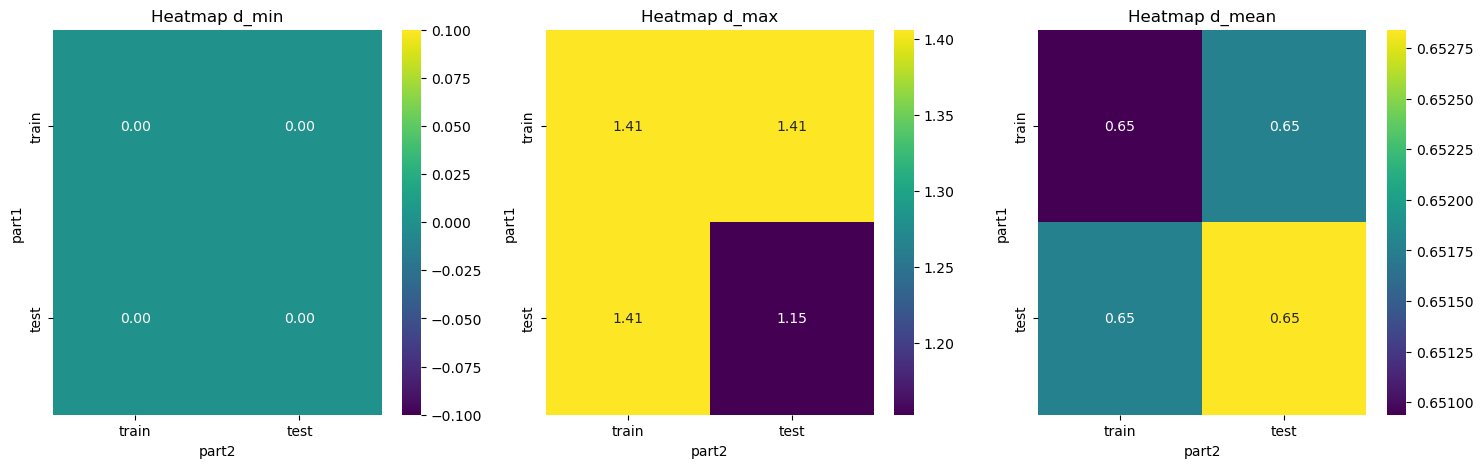

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Pivotamos para tener matriz part1 x part2

metrics = ["d_min", "d_max", "d_mean"]
for i, metric in enumerate(metrics):
    heatmap = df_stats.pivot(index="part1", columns="part2", values=metric)
    sns.heatmap(heatmap, annot=True, fmt=".2f", cmap="viridis", ax=axes[i])
    axes[i].set_title(f"Heatmap {metric}")
plt.show()

<Axes: xlabel='id', ylabel='id'>

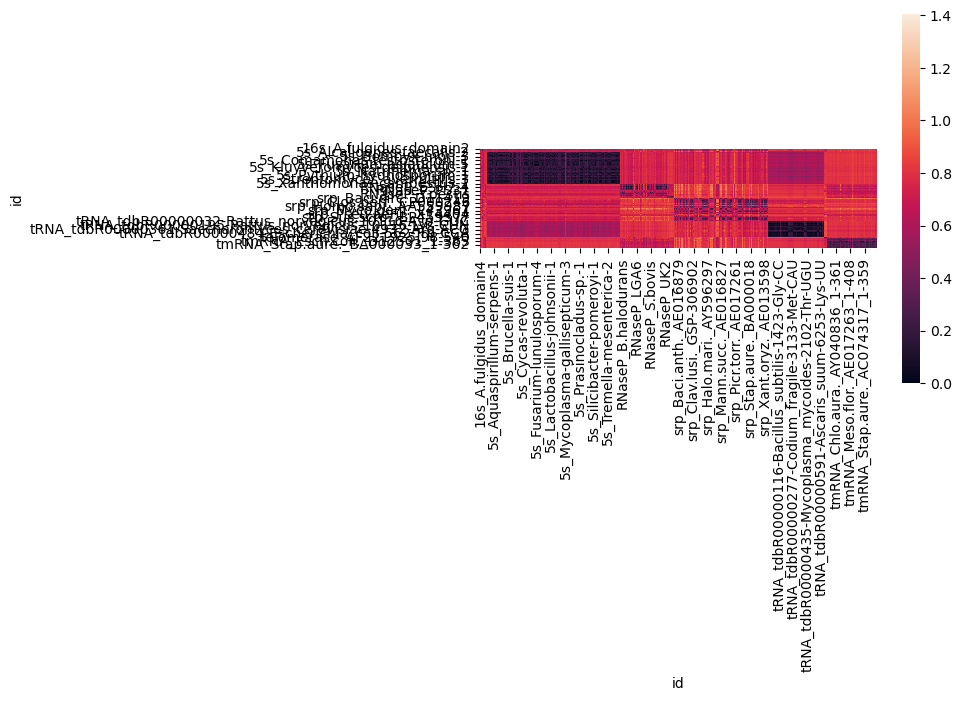

In [16]:
sns.heatmap(data=dfs['test']['train'], square=True)

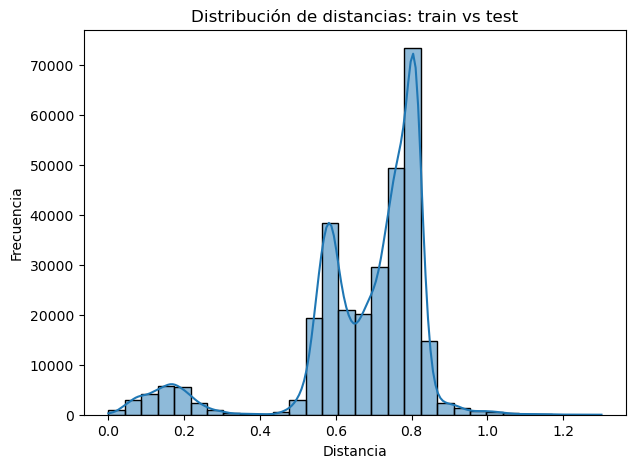

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ejemplo: histograma para una sola comparación
part1, part2 = "train", "test"
mat = dfs[part1][part2]

# Tomamos solo la parte triangular superior (sin diagonal)
vals_dist = mat.values[np.triu_indices_from(mat, k=1)]

plt.figure(figsize=(7, 5))
sns.histplot(vals_dist, bins=30, kde=True)
plt.title(f"Distribución de distancias: {part1} vs {part2}")
plt.xlabel("Distancia")
plt.ylabel("Frecuencia")
plt.show()

In [18]:
import pandas as pd

rows = []
for part1, dic in dfs.items():
    for part2, mat in dic.items():
        vals_dist = mat.values[np.triu_indices_from(mat, k=1)]
        for v in vals_dist:
            rows.append({"part1": part1, "part2": part2, "dist": v})

df_dists = pd.DataFrame(rows)
df_dists.sample(5)

,part1,part2,dist
5908472,test,train,0.695864
1090302,train,train,0.554622
750240,train,train,0.307692
6124872,test,train,0.804878
7102485,test,train,0.933884


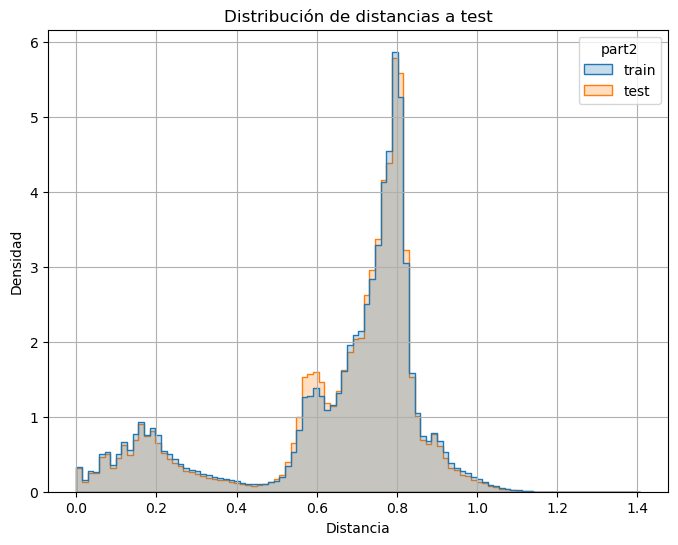

In [19]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=df_dists.query("part1 == 'test'"),
    x="dist",
    hue="part2",
    element="step",
    stat="density",
    common_norm=False,
    bins=100,
)
plt.title("Distribución de distancias a test")
plt.xlabel("Distancia")
plt.ylabel("Densidad")
plt.grid()
plt.show()

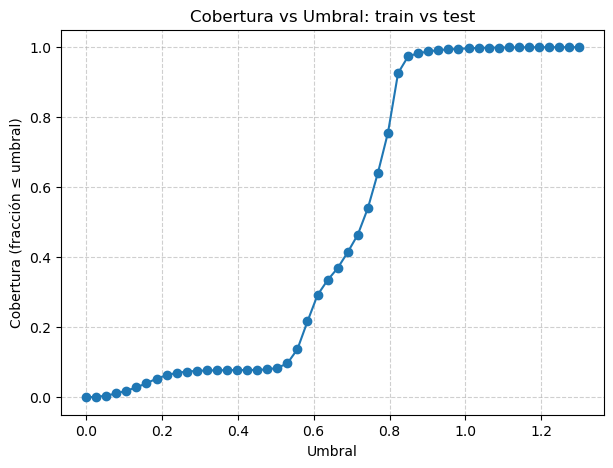

In [20]:
import numpy as np
import matplotlib.pyplot as plt

part1, part2 = "train", "test"
mat = dfs[part1][part2]
vals_dist = mat.values[np.triu_indices_from(mat, k=1)]

# Definir los umbrales
thresholds = np.linspace(0, 1.3, 50)  # suponiendo distancias en [0,1]
coverage = [(vals_dist <= t).mean() for t in thresholds]

plt.figure(figsize=(7, 5))
plt.plot(thresholds, coverage, marker="o")
plt.title(f"Cobertura vs Umbral: {part1} vs {part2}")
plt.xlabel("Umbral")
plt.ylabel("Cobertura (fracción ≤ umbral)")
plt.grid(True, ls="--", alpha=0.6)
plt.show()

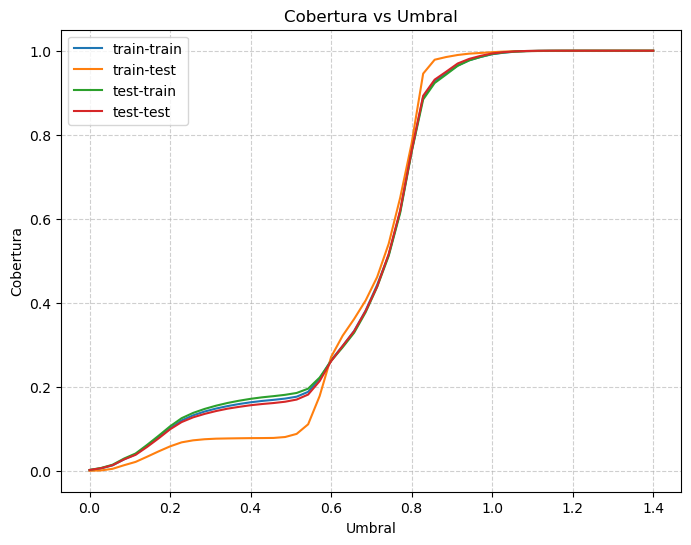

In [21]:
plt.figure(figsize=(8, 6))

for part1, dic in dfs.items():
    for part2, mat in dic.items():
        vals_dist = mat.values[np.triu_indices_from(mat, k=1)]
        thresholds = np.linspace(0, 1.4, 50)
        coverage = [(vals_dist <= t).mean() for t in thresholds]
        plt.plot(thresholds, coverage, label=f"{part1}-{part2}")

plt.title("Cobertura vs Umbral")
plt.xlabel("Umbral")
plt.ylabel("Cobertura")
plt.legend()
plt.grid(True, ls="--", alpha=0.6)
plt.show()